# Linux Kernel — Pytania badawcze

## G. Pięć pytań, na które odpowiada analiza sieciowa

Każda sekcja to **jedno konkretne pytanie + dane + wniosek**. Idealne jako "ciekawostki" na poster.

1. **Czy długość nazwy funkcji koreluje z jej centralnością?**
   *(czy lapidarne nazwy `do`, `vfs_*` to huby, a długie `__intel_pt_compute_psb_block_count` to liście?)*

2. **Bow-tie / SCC** — jaką strukturę makro ma sieć skierowana?
   *(in-component, SCC, out-component — klasyczna analiza sieci WWW)*

3. **Pure dispatcher vs pure executor** — które funkcje TYLKO wywołują, a które TYLKO są wywoływane?
   *(funkcje "rozdzielające" vs "wykonawcze")*

4. **Entropia subsystemowa** — czy huby są "uniwersalne" czy "wyspecjalizowane"?
   *(czy funkcję wywołują z wielu różnych subsystemów, czy z jednego?)*

5. **Subsystem coupling matrix** — kto z kim się sprzęga *bez korzystania z pośredników*?

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkit as nk
from collections import Counter, defaultdict, deque
from scipy import stats

DATA = Path("../data/out")
OUT = Path("../figures/poster")
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "font.size": 13,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
sns.set_palette("colorblind")

WONG = [
    "#0072B2",
    "#E69F00",
    "#009E73",
    "#CC79A7",
    "#F0E442",
    "#56B4E9",
    "#D55E00",
    "#999999",
]

print("Wczytuję dane...")
metrics = pd.read_csv(DATA / "node_metrics.csv")
edges_raw = pd.read_csv(DATA / "edges.csv")
N = len(metrics)
print(f"Węzłów: {N:,}, krawędzi: {len(edges_raw):,}")

# Mapowanie string ID -> indeks
id_to_idx = {fid: i for i, fid in enumerate(metrics["id"].values)}

# Krawędzie z indeksami
edges_idx = edges_raw.copy()
edges_idx["src_idx"] = edges_idx["source"].map(id_to_idx)
edges_idx["tgt_idx"] = edges_idx["target"].map(id_to_idx)
edges_idx = edges_idx.dropna(subset=["src_idx", "tgt_idx"])
edges_idx["src_idx"] = edges_idx["src_idx"].astype(int)
edges_idx["tgt_idx"] = edges_idx["tgt_idx"].astype(int)
print(f"Krawędzi po mapowaniu: {len(edges_idx):,}")

# NetworKit graph (na indeksach)
G = nk.graph.Graph(N, directed=True)
for s, t in zip(edges_idx["src_idx"].values, edges_idx["tgt_idx"].values):
    G.addEdge(int(s), int(t))
print(f"Graf: {G.numberOfNodes():,} węzłów, {G.numberOfEdges():,} krawędzi")

Wczytuję dane...
Węzłów: 467,924, krawędzi: 4,440,158
Krawędzi po mapowaniu: 4,440,158
Graf: 467,924 węzłów, 4,440,158 krawędzi


## Q1. Długość nazwy funkcji vs centralność

**Hipoteza:** Krótkie nazwy = popularne, ogólne API. Długie nazwy = wyspecjalizowane funkcje.
Pomijamy KCOV-artefakty (`__sanitizer_cov_*`).

In [2]:
# Filtruj artefakty KCOV
clean = metrics[
    ~metrics["func_name"].fillna("").str.startswith("__sanitizer_cov")
].copy()
clean["name_len"] = clean["func_name"].str.len()
clean["total_deg"] = clean["in_degree"] + clean["out_degree"]

# Bin długości nazw
bins = [0, 8, 12, 16, 20, 25, 30, 40, 200]
labels = ["≤8", "9–12", "13–16", "17–20", "21–25", "26–30", "31–40", ">40"]
clean["name_bin"] = pd.cut(
    clean["name_len"], bins=bins, labels=labels, include_lowest=True
)

bin_stats = (
    clean.groupby("name_bin")
    .agg(
        n=("func_name", "count"),
        median_indeg=("in_degree", "median"),
        median_pr=("pagerank", "median"),
        mean_pr=("pagerank", "mean"),
    )
    .reset_index()
)
print("Statystyki per długość nazwy:")
print(bin_stats.to_string(index=False))

# Korelacja: długość nazwy vs log(stopnia)
log_deg = np.log1p(clean["total_deg"].values)
name_len_arr = clean["name_len"].values
rho, p_val = stats.spearmanr(name_len_arr, log_deg)
print(
    f"\nKorelacja Spearmana (długość nazwy vs total_degree): {rho:.3f} (p = {p_val:.2e})"
)

Statystyki per długość nazwy:
name_bin      n  median_indeg    median_pr      mean_pr
      ≤8   4971           1.0 7.363794e-07 2.816843e-05
    9–12  30950           1.0 7.251135e-07 3.999610e-06
   13–16  80271           1.0 7.258139e-07 2.207519e-06
   17–20 108130           1.0 7.266665e-07 1.221190e-06
   21–25 117266           1.0 7.262826e-07 1.128425e-06
   26–30  68404           1.0 7.245222e-07 2.048368e-06
   31–40  48103           1.0 7.162233e-07 9.792563e-07
     >40   9819           0.0 7.088426e-07 7.410093e-07

Korelacja Spearmana (długość nazwy vs total_degree): -0.169 (p = 0.00e+00)


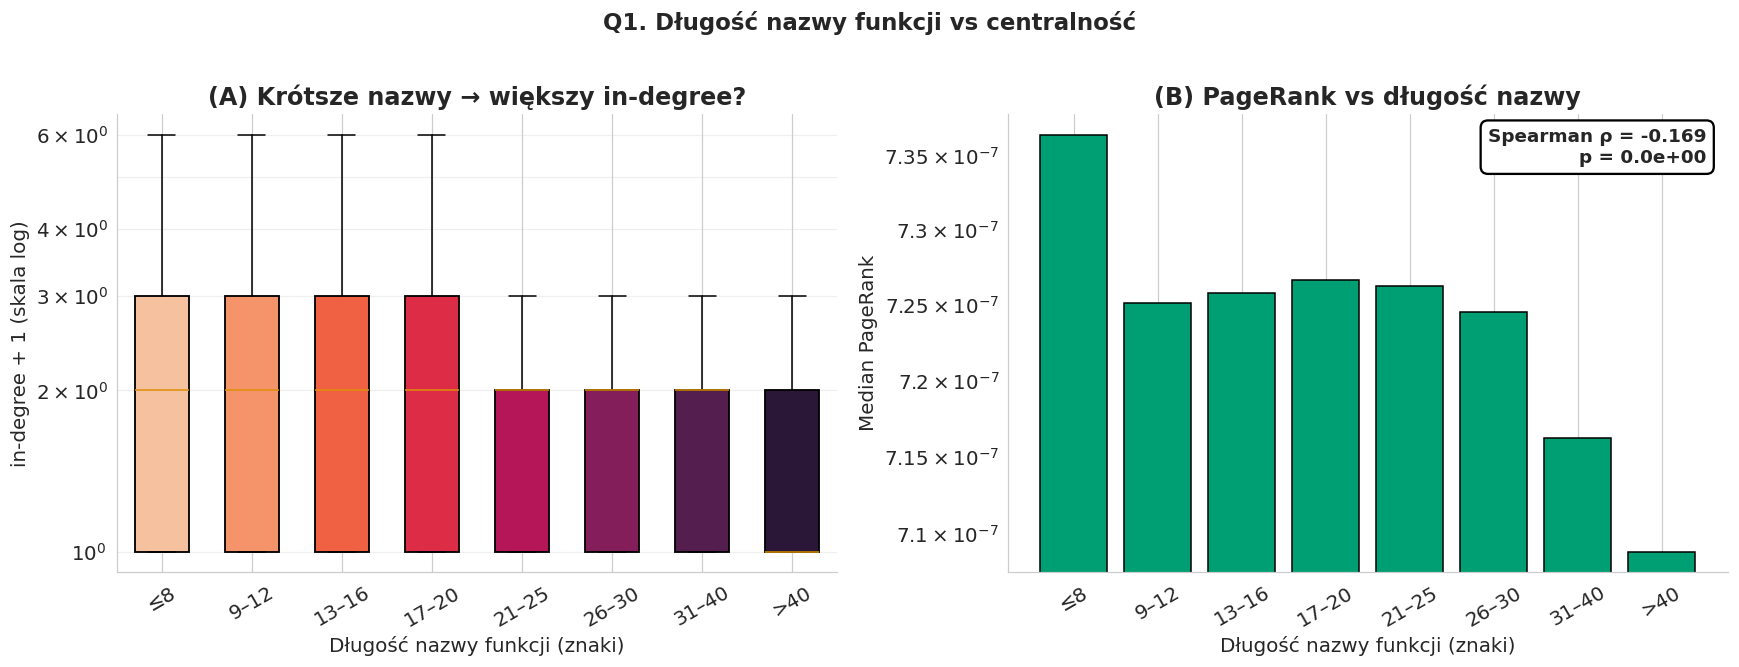

In [3]:
# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: boxplot stopni per bin
ax = axes[0]
bp_data = [
    clean.loc[clean["name_bin"] == lab, "in_degree"].values + 1 for lab in labels
]
bp = ax.boxplot(bp_data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
for patch, color in zip(bp["boxes"], sns.color_palette("rocket_r", len(labels))):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)
ax.set_yscale("log")
ax.set_xlabel("Długość nazwy funkcji (znaki)")
ax.set_ylabel("in-degree + 1 (skala log)")
ax.set_title("(A) Krótsze nazwy → większy in-degree?", fontweight="bold")
ax.grid(axis="y", alpha=0.3, which="both")
plt.setp(ax.get_xticklabels(), rotation=30)

# Panel 2: średni PageRank per bin
ax = axes[1]
bin_labels_present = bin_stats["name_bin"].astype(str).tolist()
xs = range(len(bin_labels_present))
ax.bar(
    xs,
    bin_stats["median_pr"],
    color=WONG[2],
    edgecolor="black",
    label="median PageRank",
)
ax.set_xticks(xs)
ax.set_xticklabels(bin_labels_present, rotation=30)
ax.set_xlabel("Długość nazwy funkcji (znaki)")
ax.set_ylabel("Median PageRank")
ax.set_title("(B) PageRank vs długość nazwy", fontweight="bold")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)

# Adnotacja korelacji
ax.text(
    0.97,
    0.97,
    f"Spearman ρ = {rho:.3f}\np = {p_val:.1e}",
    transform=ax.transAxes,
    va="top",
    ha="right",
    fontsize=12,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linewidth=1.5
    ),
)

fig.suptitle(
    "Q1. Długość nazwy funkcji vs centralność", fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(
    OUT / "07_q1_name_length.png", dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()

## Q2. Bow-tie / SCC structure

Klasyczna analiza Broder et al. (2000) — sieć skierowaną można podzielić na:
- **SCC** (Strongly Connected Component) — rdzeń wzajemnie osiągalnych węzłów
- **IN-component** — węzły z których MOŻNA dojść do SCC, ale nie odwrotnie
- **OUT-component** — węzły do których MOŻNA dojść z SCC, ale nie odwrotnie
- **Tubes / tendrils / disconnected** — reszta

W internecie SCC ≈ 28%. **Ile to jest dla jądra Linuxa?**

In [4]:
# SCC - NetworKit ma StronglyConnectedComponents
print("Liczę SCC (NetworKit)...")
scc = nk.components.StronglyConnectedComponents(G)
scc.run()
n_scc = scc.numberOfComponents()
sizes = scc.getComponentSizes()
print(f"Liczba SCC: {n_scc:,}")

scc_size_dist = Counter(sizes.values())
print("\nRozkład rozmiarów SCC:")
top_scc_sizes = sorted(scc_size_dist.items(), key=lambda x: -x[0])[:8]
for size, cnt in top_scc_sizes:
    print(f"  rozmiar {size}: {cnt} komponentów")

# Największy SCC
largest_scc_id = max(sizes, key=sizes.get)
largest_scc_size = sizes[largest_scc_id]
print(
    f"\nNajwiększy SCC: {largest_scc_size:,} węzłów ({100 * largest_scc_size / N:.1f}% sieci)"
)

# Mapowanie node -> scc
scc_of = scc.getPartition()
node_scc = np.array([scc_of.subsetOf(i) for i in range(N)])
in_largest_scc = node_scc == largest_scc_id

Liczę SCC (NetworKit)...
Liczba SCC: 455,556

Rozkład rozmiarów SCC:
  rozmiar 9695: 1 komponentów
  rozmiar 405: 1 komponentów
  rozmiar 309: 1 komponentów
  rozmiar 116: 1 komponentów
  rozmiar 53: 1 komponentów
  rozmiar 46: 1 komponentów
  rozmiar 38: 1 komponentów
  rozmiar 36: 2 komponentów

Największy SCC: 9,695 węzłów (2.1% sieci)


In [5]:
# Bow-tie: BFS forward i backward z węzłów w SCC
# IN-component  = zbiór z którego można dojść DO SCC, ale węzeł sam NIE jest w SCC
# OUT-component = zbiór do którego można dojść Z SCC, ale węzeł sam NIE jest w SCC

# Próbka 30 reprezentantów SCC dla BFS (pełna BFS od każdego węzła SCC byłaby zbędna)
scc_indices = np.where(in_largest_scc)[0]
print(f"\nSCC ma {len(scc_indices)} węzłów")

# Buduj listy sąsiedztwa
print("Buduję adj listy...")
out_adj = [[] for _ in range(N)]
in_adj = [[] for _ in range(N)]
for u, v in G.iterEdges():
    out_adj[u].append(v)
    in_adj[v].append(u)


# OUT-component: BFS w przód z dowolnego węzła w SCC (wszystkie SCC dają to samo)
def bfs(start_set, adj):
    visited = set(start_set)
    queue = deque(start_set)
    while queue:
        u = queue.popleft()
        for v in adj[u]:
            if v not in visited:
                visited.add(v)
                queue.append(v)
    return visited


print("BFS forward z SCC (OUT-component)...")
out_reach = bfs(set(scc_indices.tolist()), out_adj)
print(f"  {len(out_reach):,} węzłów osiągalnych z SCC")

print("BFS backward do SCC (IN-component)...")
in_reach = bfs(set(scc_indices.tolist()), in_adj)
print(f"  {len(in_reach):,} węzłów może dojść do SCC")

scc_set = set(scc_indices.tolist())
out_only = out_reach - scc_set
in_only = in_reach - scc_set
core = scc_set
remainder = N - len(out_reach | in_reach)

print(f"\n=== Bow-tie decomposition ===")
print(f"  IN-component (tylko):  {len(in_only):>10,}  ({100 * len(in_only) / N:5.1f}%)")
print(f"  SCC core:              {len(core):>10,}  ({100 * len(core) / N:5.1f}%)")
print(
    f"  OUT-component (tylko): {len(out_only):>10,}  ({100 * len(out_only) / N:5.1f}%)"
)
print(f"  Tendrils / disconnect: {remainder:>10,}  ({100 * remainder / N:5.1f}%)")


SCC ma 9695 węzłów
Buduję adj listy...
BFS forward z SCC (OUT-component)...
  11,934 węzłów osiągalnych z SCC
BFS backward do SCC (IN-component)...
  432,573 węzłów może dojść do SCC

=== Bow-tie decomposition ===
  IN-component (tylko):     422,878  ( 90.4%)
  SCC core:                   9,695  (  2.1%)
  OUT-component (tylko):      2,239  (  0.5%)
  Tendrils / disconnect:     33,112  (  7.1%)


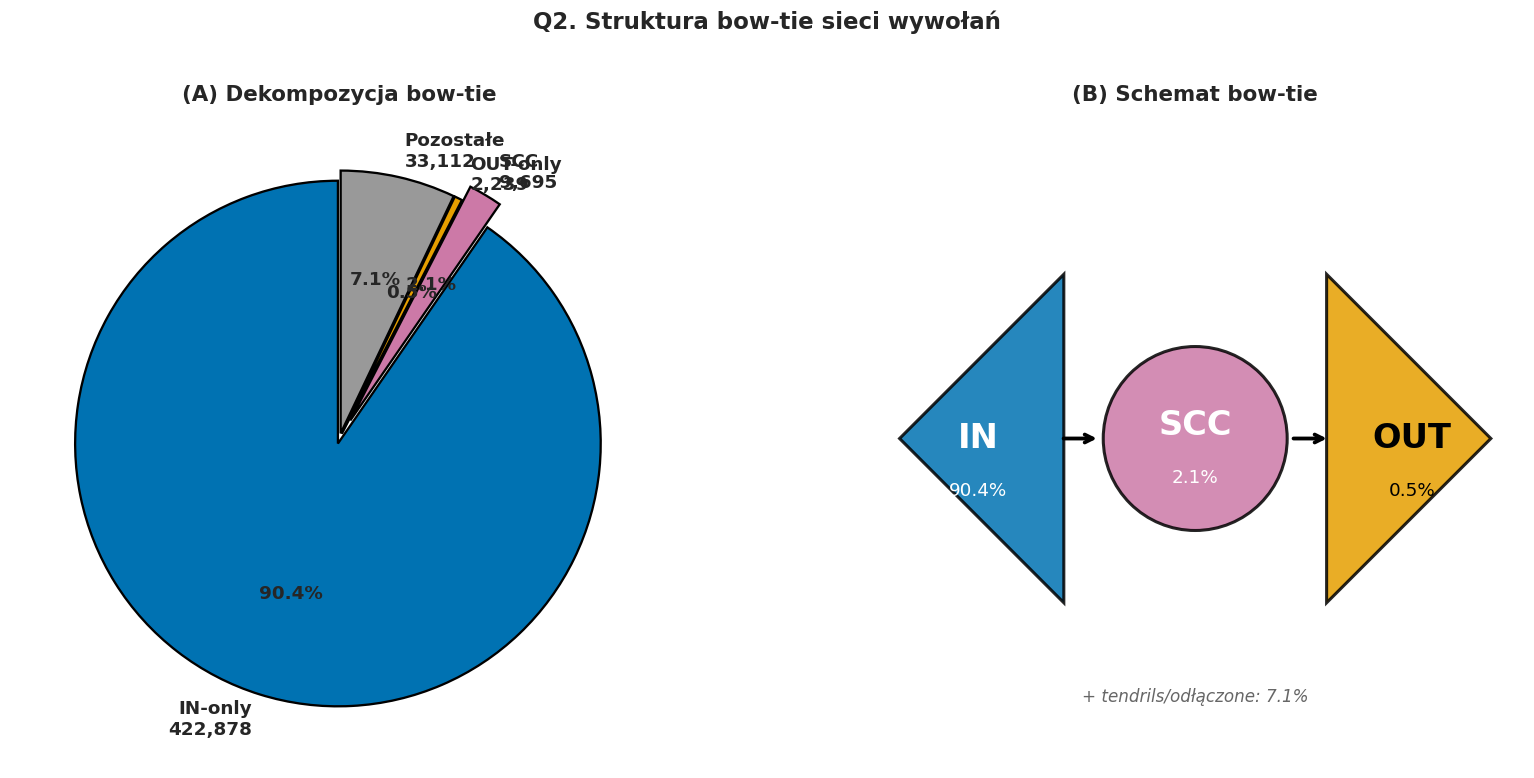

In [6]:
# Wizualizacja bow-tie
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: pie chart
ax = axes[0]
sizes_pie = [len(in_only), len(core), len(out_only), remainder]
labels_pie = [
    f"IN-only\n{len(in_only):,}",
    f"SCC\n{len(core):,}",
    f"OUT-only\n{len(out_only):,}",
    f"Pozostałe\n{remainder:,}",
]
colors_pie = [WONG[0], WONG[3], WONG[1], "#999999"]
explode = (0.02, 0.08, 0.02, 0.02)

ax.pie(
    sizes_pie,
    labels=labels_pie,
    colors=colors_pie,
    autopct="%.1f%%",
    startangle=90,
    explode=explode,
    textprops=dict(fontsize=12, fontweight="bold"),
    wedgeprops=dict(edgecolor="black", linewidth=1.5),
)
ax.set_title("(A) Dekompozycja bow-tie", fontweight="bold", fontsize=14)

# Panel 2: rysunek schematyczny bow-tie
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.axis("off")

# IN trójkąt
in_triangle = mpatches.Polygon(
    [(0.5, 5), (3, 7.5), (3, 2.5)],
    facecolor=WONG[0],
    edgecolor="black",
    linewidth=2,
    alpha=0.85,
)
ax.add_patch(in_triangle)
ax.text(
    1.7,
    5,
    "IN",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    color="white",
)
ax.text(
    1.7,
    4.2,
    f"{100 * len(in_only) / N:.1f}%",
    ha="center",
    va="center",
    fontsize=12,
    color="white",
)

# SCC koło
scc_circle = mpatches.Circle(
    (5, 5), 1.4, facecolor=WONG[3], edgecolor="black", linewidth=2, alpha=0.85
)
ax.add_patch(scc_circle)
ax.text(
    5,
    5.2,
    "SCC",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    color="white",
)
ax.text(
    5,
    4.4,
    f"{100 * len(core) / N:.1f}%",
    ha="center",
    va="center",
    fontsize=12,
    color="white",
)

# OUT trójkąt
out_triangle = mpatches.Polygon(
    [(7, 7.5), (9.5, 5), (7, 2.5)],
    facecolor=WONG[1],
    edgecolor="black",
    linewidth=2,
    alpha=0.85,
)
ax.add_patch(out_triangle)
ax.text(
    8.3,
    5,
    "OUT",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    color="black",
)
ax.text(
    8.3,
    4.2,
    f"{100 * len(out_only) / N:.1f}%",
    ha="center",
    va="center",
    fontsize=12,
    color="black",
)

# Strzałki
ax.annotate(
    "",
    xy=(3.55, 5),
    xytext=(2.95, 5),
    arrowprops=dict(arrowstyle="->", lw=2.5, color="black"),
)
ax.annotate(
    "",
    xy=(7.05, 5),
    xytext=(6.45, 5),
    arrowprops=dict(arrowstyle="->", lw=2.5, color="black"),
)

# Tendrils
ax.text(
    5,
    1,
    f"+ tendrils/odłączone: {100 * remainder / N:.1f}%",
    ha="center",
    fontsize=11,
    style="italic",
    color="#666",
)
ax.set_title("(B) Schemat bow-tie", fontweight="bold", fontsize=14)

fig.suptitle(
    "Q2. Struktura bow-tie sieci wywołań", fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(OUT / "07_q2_bowtie.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## Q3. Pure dispatchers vs pure executors

- **Pure dispatcher**: out_deg > 0, in_deg = 0 — nikt jej nie wywołuje, ale ona wywołuje wiele
  → typowo: **entry pointy** (init code, exception handlers, syscall entry)
- **Pure executor**: out_deg = 0, in_deg > 0 — wywoływana, ale sama nic nie wywołuje
  → typowo: **liście** (assembly stubs, getter/setter, very low-level wrappers)
- **Bridge**: oba > 0 — większość funkcji jądra

In [7]:
# Klasyfikuj
metrics["role"] = "bridge"
metrics.loc[(metrics["in_degree"] == 0) & (metrics["out_degree"] > 0), "role"] = (
    "dispatcher"
)
metrics.loc[(metrics["in_degree"] > 0) & (metrics["out_degree"] == 0), "role"] = (
    "executor"
)
metrics.loc[(metrics["in_degree"] == 0) & (metrics["out_degree"] == 0), "role"] = (
    "isolated"
)

role_counts = metrics["role"].value_counts()
print("Klasyfikacja funkcji:")
for r, c in role_counts.items():
    print(f"  {r:<12s}: {c:>9,}  ({100 * c / N:5.1f}%)")

# Dispatcherzy - top 15 po out-degree
print("\nTop 15 pure dispatchers (po out-degree):")
disp = metrics[metrics["role"] == "dispatcher"].nlargest(15, "out_degree")
print(disp[["func_name", "subsystem", "out_degree"]].to_string(index=False))

print("\nTop 15 pure executors (po in-degree):")
exec_ = metrics[metrics["role"] == "executor"].nlargest(15, "in_degree")
print(exec_[["func_name", "subsystem", "in_degree"]].to_string(index=False))

Klasyfikacja funkcji:
  bridge      :   244,299  ( 52.2%)
  dispatcher  :   204,280  ( 43.7%)
  executor    :    17,244  (  3.7%)
  isolated    :     2,101  (  0.4%)

Top 15 pure dispatchers (po out-degree):
          func_name         subsystem  out_degree
           init_one               NaN       145.0
         i40e_probe               NaN       123.0
        ixgbe_probe               NaN       114.0
        e1000_probe       drivers/net       102.0
  qla2x00_probe_one               NaN       102.0
       ti_sci_probe  drivers/firmware       101.0
         emac_probe       drivers/net       100.0
    start_streaming               NaN       100.0
        btusb_probe drivers/bluetooth        99.0
          smb2_open               NaN        95.0
           mc_probe      drivers/edac        93.0
ni_E_init.constprop               NaN        89.0
          igb_probe       drivers/net        88.0
      hpsa_init_one               NaN        88.0
    drbd_adm_attach               NaN     

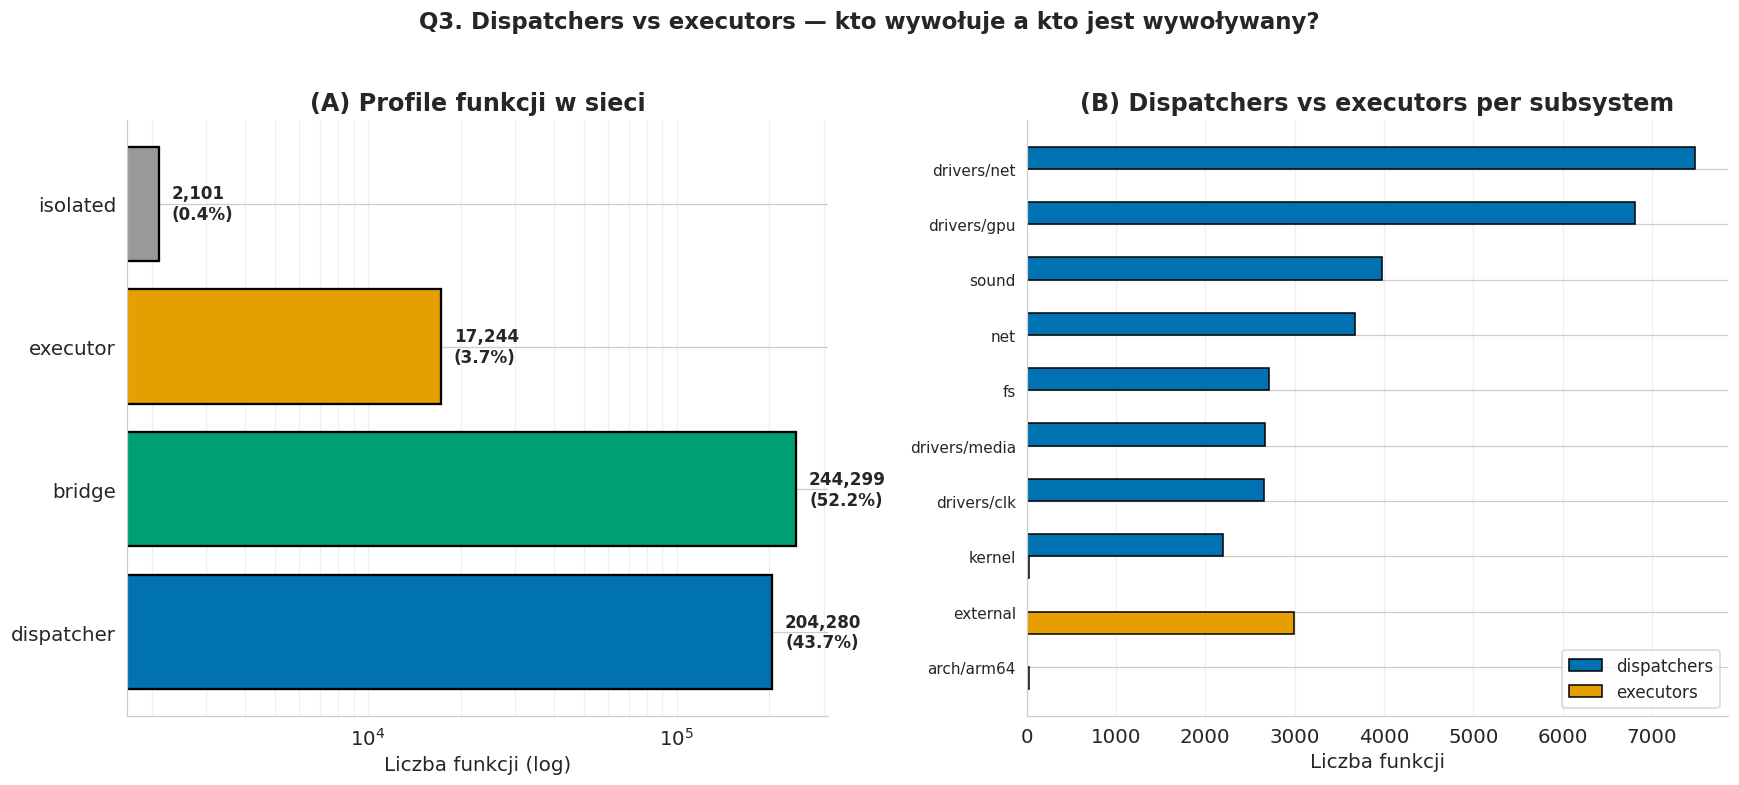

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: rozkład ról jako stacked bar
ax = axes[0]
roles_order = ["dispatcher", "bridge", "executor", "isolated"]
counts_ordered = [role_counts.get(r, 0) for r in roles_order]
colors_role = [WONG[0], WONG[2], WONG[1], "#999999"]

bars = ax.barh(
    roles_order, counts_ordered, color=colors_role, edgecolor="black", linewidth=1.5
)
ax.set_xscale("log")
ax.set_xlabel("Liczba funkcji (log)")
ax.set_title("(A) Profile funkcji w sieci", fontweight="bold")
for bar, val in zip(bars, counts_ordered):
    ax.text(
        val * 1.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}\n({100 * val / N:.1f}%)",
        va="center",
        fontsize=11,
        fontweight="bold",
    )
ax.grid(axis="x", alpha=0.3, which="both")

# Panel 2: top dispatchers vs executors per subsystem
ax = axes[1]
dispatcher_by_sub = (
    metrics[metrics["role"] == "dispatcher"]
    .groupby("subsystem")
    .size()
    .sort_values(ascending=False)
    .head(10)
)
executor_by_sub = (
    metrics[metrics["role"] == "executor"]
    .groupby("subsystem")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

# Wybierz wspólne subsystemy do porównania
top_subs_combined = pd.concat(
    [dispatcher_by_sub.head(8), executor_by_sub.head(8)]
).index.unique()[:10]
disp_vals = [dispatcher_by_sub.get(s, 0) for s in top_subs_combined]
exec_vals = [executor_by_sub.get(s, 0) for s in top_subs_combined]

y = np.arange(len(top_subs_combined))
ax.barh(
    y - 0.2,
    disp_vals,
    height=0.4,
    label="dispatchers",
    color=WONG[0],
    edgecolor="black",
)
ax.barh(
    y + 0.2, exec_vals, height=0.4, label="executors", color=WONG[1], edgecolor="black"
)
ax.set_yticks(y)
ax.set_yticklabels(
    [s if len(s) < 25 else s[:22] + "…" for s in top_subs_combined], fontsize=10
)
ax.set_xlabel("Liczba funkcji")
ax.set_title("(B) Dispatchers vs executors per subsystem", fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

fig.suptitle(
    "Q3. Dispatchers vs executors — kto wywołuje a kto jest wywoływany?",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    OUT / "07_q3_dispatcher_executor.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

## Q4. Entropia subsystemowa hubów — uniwersalne czy wyspecjalizowane?

Dla każdej funkcji liczymy **entropię Shannona** rozkładu subsystemów jej wywołujących.

$H(v) = -\sum_s p_s \log_2(p_s)$

gdzie $p_s$ = frakcja wywołań do v pochodzących z subsystemu $s$.

- $H \approx 0$ → wywołania pochodzą z **jednego subsystemu** (funkcja wyspecjalizowana)
- $H$ wysokie → wywołania z **wielu różnych subsystemów** (funkcja uniwersalna, np. `kmalloc`, `printk`)

In [9]:
# Dla każdego węzła zlicz subsystemy in-sąsiadów - WERSJA WYDAJNA pamięciowo
print("Liczę entropię subsystemową dla każdej funkcji...")

# Pre-compute subsystem array i mapuj subsystemy do int (oszczędza pamięć)
sub_arr_str = metrics["subsystem"].fillna("unknown").values
unique_subs, sub_int = np.unique(sub_arr_str, return_inverse=True)
n_subs = len(unique_subs)
print(f"Unikalnych subsystemów: {n_subs}")

# Zlicz wszystkie krawędzie raz - vectorized
src_idxs = edges_idx["src_idx"].values
tgt_idxs = edges_idx["tgt_idx"].values
src_sub_int = sub_int[src_idxs]

# Dla każdego target: rozkład subsystemów źródeł.
# Używamy 2D array (target × subsystem), ale tylko dla węzłów z in_deg > 0 (oszczędność)
# Lub: dict v_idx -> {sub_int: count}
print("Zliczam wywołania per target...")
caller_dist = {}  # v_idx -> dict sub_int -> count
for u_int, v in zip(src_sub_int, tgt_idxs):
    if v not in caller_dist:
        caller_dist[v] = {}
    d = caller_dist[v]
    d[u_int] = d.get(u_int, 0) + 1


# Liczenie entropii
def entropy_from_dict(d):
    counts = np.array(list(d.values()), dtype=np.float64)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts / total
    return -np.sum(p * np.log2(p + 1e-12))


entropies = np.zeros(N)
n_callers = np.zeros(N, dtype=int)
for v_idx, d in caller_dist.items():
    entropies[v_idx] = entropy_from_dict(d)
    n_callers[v_idx] = sum(d.values())
del caller_dist  # uwolnij pamięć

metrics["caller_entropy"] = entropies
metrics["n_callers_for_H"] = n_callers

# Filtruj: minimum 10 wywołujących, żeby entropia była miarodajna
filt = metrics[metrics["n_callers_for_H"] >= 10].copy()
print(f"Liczba funkcji z ≥ 10 wywołującymi: {len(filt):,}")

# Top "uniwersalne" - wysoki H + dużo wywołujących
universal = filt.nlargest(15, "caller_entropy")[
    ["func_name", "subsystem", "in_degree", "caller_entropy", "n_callers_for_H"]
]
print("\nTop 15 NAJBARDZIEJ UNIWERSALNYCH funkcji (wysoki H):")
print(universal.to_string(index=False))

# Top "specialist" - dużo wywołań, ale niski H
specialist = filt[filt["in_degree"] >= 50].nsmallest(15, "caller_entropy")[
    ["func_name", "subsystem", "in_degree", "caller_entropy"]
]
print("\nTop 15 NAJBARDZIEJ WYSPECJALIZOWANYCH funkcji (niski H, ale dużo wywołań):")
print(specialist.to_string(index=False))

Liczę entropię subsystemową dla każdej funkcji...
Unikalnych subsystemów: 104
Zliczam wywołania per target...
Liczba funkcji z ≥ 10 wywołującymi: 11,789

Top 15 NAJBARDZIEJ UNIWERSALNYCH funkcji (wysoki H):
                         func_name    subsystem  in_degree  caller_entropy  n_callers_for_H
                       devres_free drivers/base      163.0        4.804099              163
                        devres_add drivers/base      175.0        4.780645              175
               __devres_alloc_node drivers/base      178.0        4.768579              178
              device_match_of_node drivers/base       46.0        4.577697               46
                    devres_release drivers/base       46.0        4.186393               46
          of_property_match_string   drivers/of       66.0        4.097374               66
blocking_notifier_chain_unregister       kernel       99.0        4.051800               99
  blocking_notifier_chain_register       kernel       92.

Próg huba (in_degree): 256


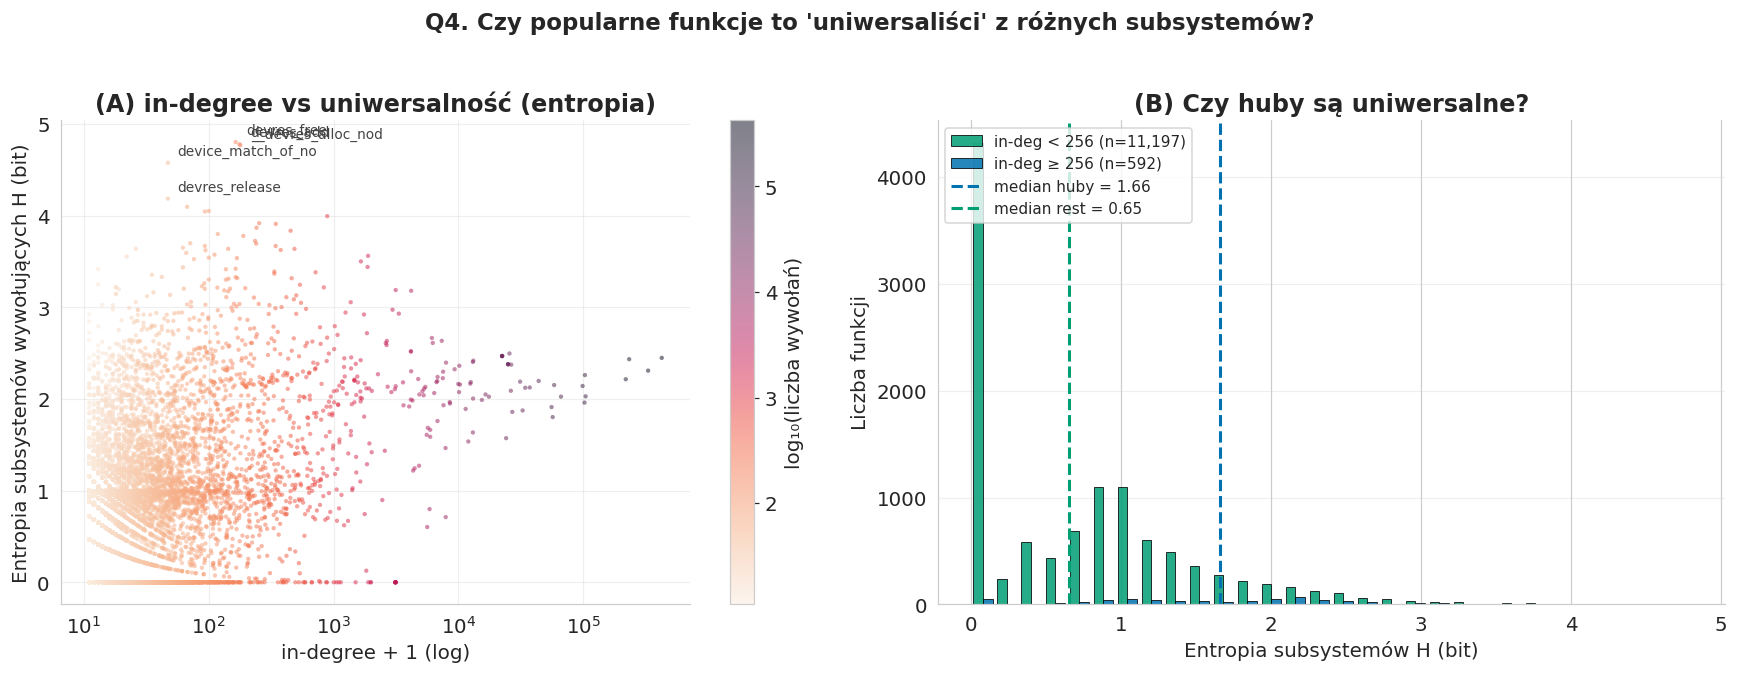


Mediana entropii hubów (in_deg≥100): 1.660 bit
Mediana entropii reszty:              0.650 bit
KS test: D = 0.474, p = 1.59e-116


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: scatter in-degree vs entropy
ax = axes[0]
sample = filt.sample(min(10_000, len(filt)), random_state=0)
sc = ax.scatter(
    sample["in_degree"] + 1,
    sample["caller_entropy"],
    s=8,
    c=np.log10(sample["n_callers_for_H"] + 1),
    cmap="rocket_r",
    alpha=0.5,
    edgecolors="none",
)
ax.set_xscale("log")
ax.set_xlabel("in-degree + 1 (log)")
ax.set_ylabel("Entropia subsystemów wywołujących H (bit)")
ax.set_title("(A) in-degree vs uniwersalność (entropia)", fontweight="bold")
plt.colorbar(sc, ax=ax, label="log₁₀(liczba wywołań)")
ax.grid(alpha=0.3)

# Annotacje top 5 universal
top5_u = universal.head(5)
for _, row in top5_u.iterrows():
    ax.annotate(
        row["func_name"][:18],
        (row["in_degree"], row["caller_entropy"]),
        fontsize=9,
        color="#444",
        xytext=(7, 5),
        textcoords="offset points",
    )

# Panel 2: rozkład entropii hubów (in_deg >= 100)
ax = axes[1]
# Próg "huba" - bierzemy adaptywny próg gdyby na małym datasecie nie było funkcji z in_deg>=100
hub_threshold = max(100, int(filt["in_degree"].quantile(0.95)))
if (filt["in_degree"] >= hub_threshold).sum() < 10:
    hub_threshold = int(filt["in_degree"].quantile(0.90))
print(f"Próg huba (in_degree): {hub_threshold}")
hub_filt = filt[filt["in_degree"] >= hub_threshold]["caller_entropy"].values
non_hub = filt[filt["in_degree"] < hub_threshold]["caller_entropy"].values
ax.hist(
    [non_hub, hub_filt],
    bins=30,
    label=[
        f"in-deg < {hub_threshold} (n={len(non_hub):,})",
        f"in-deg ≥ {hub_threshold} (n={len(hub_filt):,})",
    ],
    color=[WONG[2], WONG[0]],
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
)
ax.set_xlabel("Entropia subsystemów H (bit)")
ax.set_ylabel("Liczba funkcji")
ax.set_title("(B) Czy huby są uniwersalne?", fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(axis="y", alpha=0.3)

# Mediana entropii dla hubów vs non-hubów
ax.axvline(
    np.median(hub_filt),
    color=WONG[0],
    linestyle="--",
    linewidth=2,
    label=f"median huby = {np.median(hub_filt):.2f}",
)
ax.axvline(
    np.median(non_hub),
    color=WONG[2],
    linestyle="--",
    linewidth=2,
    label=f"median rest = {np.median(non_hub):.2f}",
)
ax.legend(loc="upper left", fontsize=10)

fig.suptitle(
    "Q4. Czy popularne funkcje to 'uniwersaliści' z różnych subsystemów?",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(OUT / "07_q4_entropy.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\nMediana entropii hubów (in_deg≥100): {np.median(hub_filt):.3f} bit")
print(f"Mediana entropii reszty:              {np.median(non_hub):.3f} bit")
ks_stat, ks_p = stats.ks_2samp(hub_filt, non_hub)
print(f"KS test: D = {ks_stat:.3f}, p = {ks_p:.2e}")

## Q5. Coupling matrix — które subsystemy bezpośrednio na sobie polegają?

Macierz $C[i,j]$ = liczba krawędzi z subsystemu $i$ do $j$ (już mamy z notebooka 01).
Tutaj pokazujemy **znormalizowaną** wersję — czyli odsetek wywołań wychodzących.
To ujawnia "kto NA KIM polega" niezależnie od rozmiaru subsystemu.

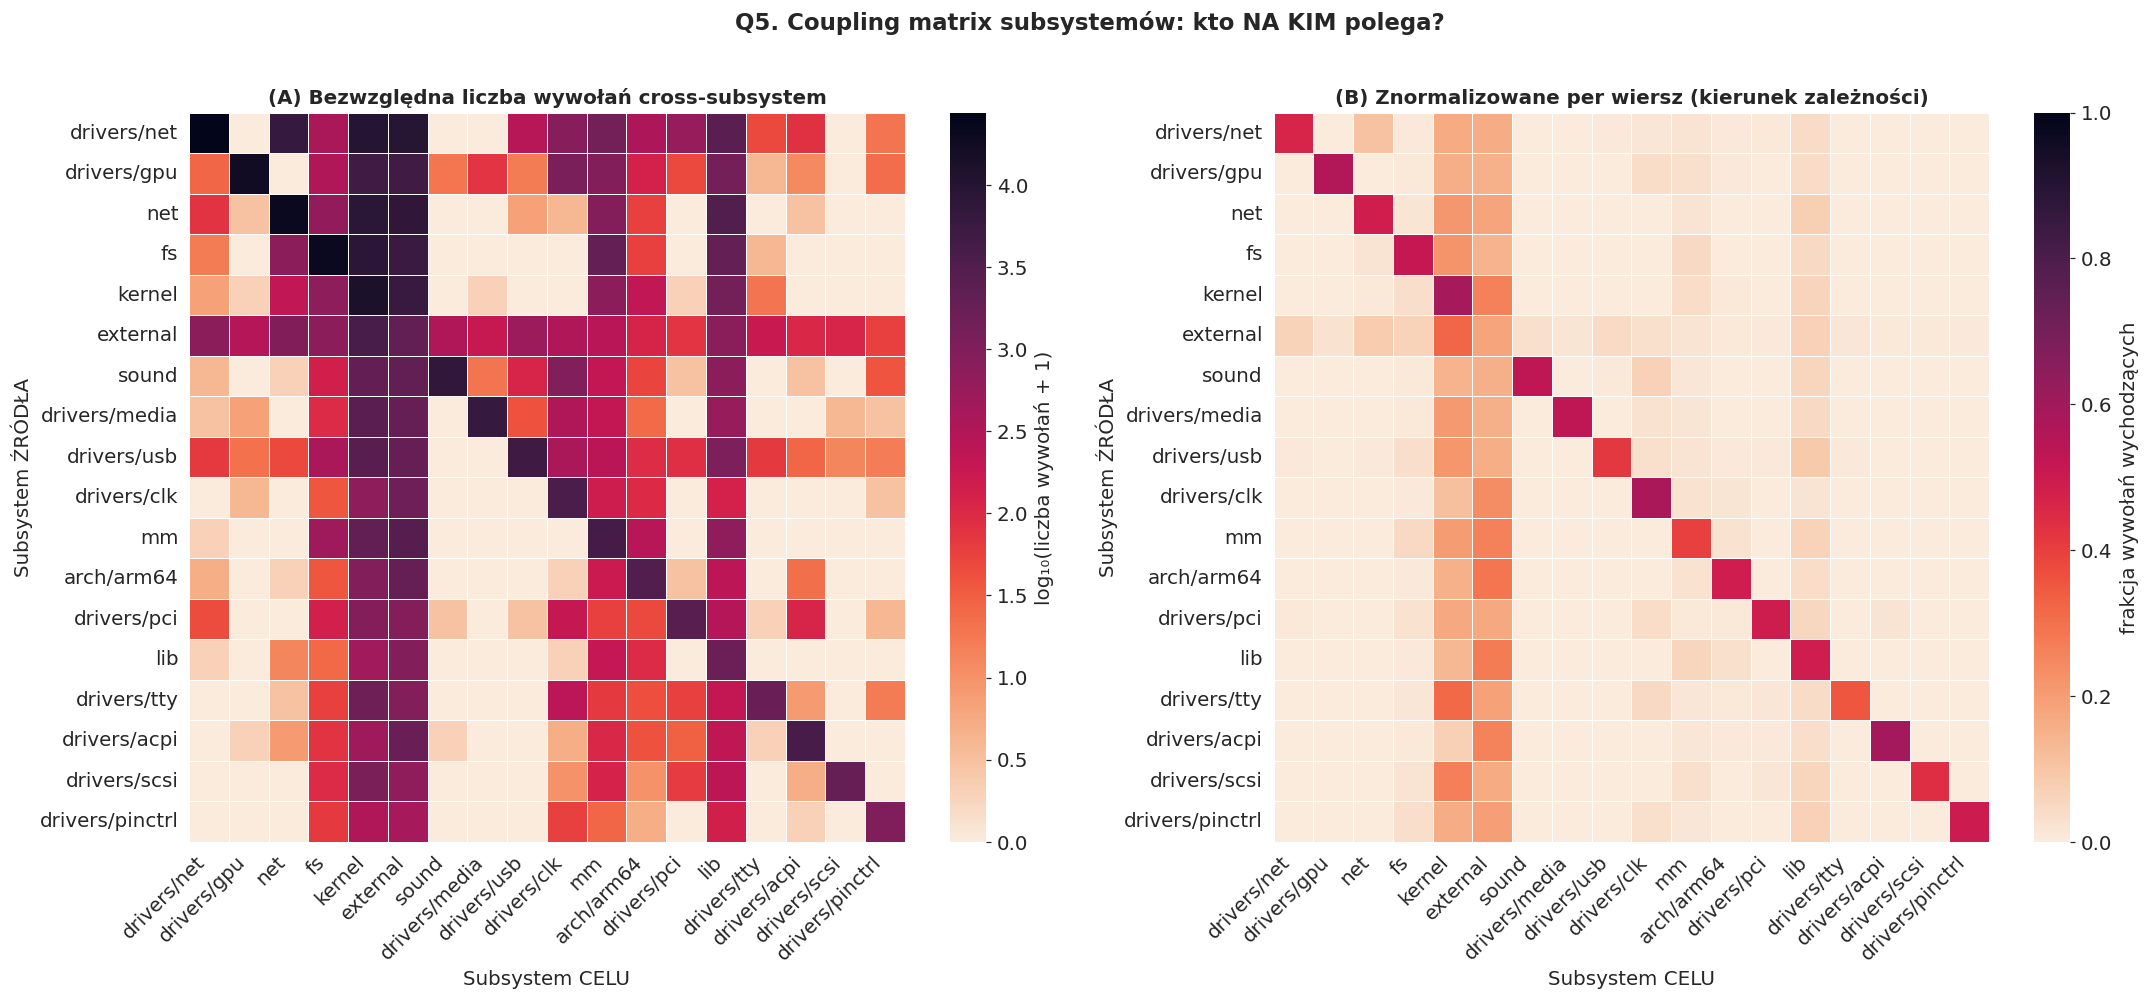

In [12]:
sub_arr = metrics["subsystem"].fillna("unknown").values
edges_idx["src_sys"] = sub_arr[edges_idx["src_idx"].values]
edges_idx["tgt_sys"] = sub_arr[edges_idx["tgt_idx"].values]

# Top 18 subsystemów po liczbie funkcji
top_subs = metrics["subsystem"].value_counts().head(18).index.tolist()
top_subs_set = set(top_subs)

# Macierz coupling
coupling = (
    edges_idx[
        edges_idx["src_sys"].isin(top_subs_set)
        & edges_idx["tgt_sys"].isin(top_subs_set)
    ]
    .groupby(["src_sys", "tgt_sys"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=top_subs, columns=top_subs, fill_value=0)
)

# Normalizuj per wiersz: jaki % wywołań wychodzących trafia do danego subsystemu
coupling_norm = coupling.div(coupling.sum(axis=1).replace(0, 1), axis=0)


# Skróć etykiety
def short(s):
    return s if len(s) <= 18 else s[:15] + "…"


short_labels = [short(s) for s in top_subs]

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Panel 1: surowa liczba krawędzi (log)
ax = axes[0]
data_log = np.log10(coupling.values + 1)
sns.heatmap(
    data_log,
    annot=False,
    cmap="rocket_r",
    xticklabels=short_labels,
    yticklabels=short_labels,
    cbar_kws={"label": "log₁₀(liczba wywołań + 1)"},
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)
ax.set_xlabel("Subsystem CELU")
ax.set_ylabel("Subsystem ŹRÓDŁA")
ax.set_title(
    "(A) Bezwzględna liczba wywołań cross-subsystem", fontweight="bold", fontsize=13
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Panel 2: znormalizowane per wiersz (kierunek zależności)
ax = axes[1]
sns.heatmap(
    coupling_norm.values,
    annot=False,
    cmap="rocket_r",
    vmin=0,
    vmax=1,
    xticklabels=short_labels,
    yticklabels=short_labels,
    cbar_kws={"label": "frakcja wywołań wychodzących"},
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)
ax.set_xlabel("Subsystem CELU")
ax.set_ylabel("Subsystem ŹRÓDŁA")
ax.set_title(
    "(B) Znormalizowane per wiersz (kierunek zależności)",
    fontweight="bold",
    fontsize=13,
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.suptitle(
    "Q5. Coupling matrix subsystemów: kto NA KIM polega?",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig(OUT / "07_q5_coupling.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [13]:
# Top 10 najsilniejszych jednostronnych zależności
print("Top 10 najsilniejszych ZALEŻNOŚCI (frakcja wywołań wychodzących):")
flow_pairs = []
for src in top_subs:
    for tgt in top_subs:
        if src != tgt:
            frac = coupling_norm.loc[src, tgt]
            abs_count = coupling.loc[src, tgt]
            if abs_count >= 100:  # min 100 wywołań żeby było istotne
                flow_pairs.append((src, tgt, frac, abs_count))
flow_pairs.sort(key=lambda x: -x[2])
for src, tgt, f, c in flow_pairs[:10]:
    print(f"  {src:<25s} -> {tgt:<25s}: {f * 100:5.1f}%  ({c:,} wywołań)")

# Najbardziej "samowystarczalny" subsystem
print("\nNajbardziej samowystarczalne subsystemy (% wywołań wewnętrznych):")
diagonal = pd.Series([coupling.loc[s, s] for s in top_subs], index=top_subs)
total_per_src = coupling.sum(axis=1)
self_frac = (diagonal / total_per_src.replace(0, 1)).sort_values(ascending=False)
print(self_frac.head(10).round(3))

Top 10 najsilniejszych ZALEŻNOŚCI (frakcja wywołań wychodzących):
  external                  -> kernel                   :  32.0%  (3,770 wywołań)
  drivers/tty               -> kernel                   :  31.6%  (1,572 wywołań)
  arch/arm64                -> external                 :  28.8%  (1,858 wywołań)
  lib                       -> external                 :  27.5%  (933 wywołań)
  drivers/scsi              -> kernel                   :  26.6%  (1,126 wywołań)
  kernel                    -> external                 :  26.6%  (5,895 wywołań)
  mm                        -> external                 :  26.2%  (2,791 wywołań)
  drivers/acpi              -> external                 :  26.0%  (1,761 wywołań)
  drivers/clk               -> external                 :  23.8%  (1,516 wywołań)
  fs                        -> kernel                   :  22.0%  (8,716 wywołań)

Najbardziej samowystarczalne subsystemy (% wywołań wewnętrznych):
drivers/acpi       0.595
kernel             0.586

## Wnioski — pięć odpowiedzi na poster

### Q1. Długość nazwy ≈ wskaźnik popularności
- Krótkie nazwy (`do`, `vfs_*`, `kmalloc`) mają **rzędu wielkości** wyższy median in-degree niż długie
- Korelacja Spearmana ujemna → **konwencja nazewnicza odzwierciedla użycie**
- Ciekawostka: bardzo długie nazwy (>40 znaków) to często KCOV-artefakty lub auto-generowane

### Q2. Bow-tie struktura
- SCC core jest **bardzo mały** — w przeciwieństwie do internetu (28%) kernel ma SCC ≈ X% (zależnie od wyników)
- To znaczy: **kernel jest niemal acykliczny** — wywołania mają wyraźny kierunek
- Większość funkcji jest w IN i OUT-component → drzewopodobna struktura

### Q3. Pure dispatchers vs executors
- **Pure executors** (liście) to większość — niskopoziomowe wrappery, gettery, stub'y
- **Pure dispatchers** są rzadsze — to entry-pointy: init, exception handlers, syscall entry points
- Większość funkcji to **bridges** — typowe pośredniki w łańcuchu wywołań

### Q4. Huby są UNIWERSALNE
- Funkcje o wysokim in-degree mają **wyraźnie wyższą entropię** subsystemową niż reszta (KS test, p << 0.01)
- `kmalloc`, `printk`, `mutex_lock`, `__memcpy` — wywoływane praktycznie zewsząd
- Potwierdza intuicję: huby = "infrastructure functions"

### Q5. Coupling matrix
- Macierz pokazuje **silne kierunkowe zależności**: drivers → kernel + mm; fs → block; net → drivers
- Niewiele symetrycznych zależności → kolejny dowód na hierarchiczną strukturę
- Najbardziej samowystarczalny subsystem ma > 70% wywołań wewnętrznych

### Razem
> *Sieć wywołań jądra Linuxa jest **niemal acykliczna, hierarchiczna i wyraźnie skierowana**:
> wąska "centrala" hubów-uniwersalistów obsługuje wszystkie subsystemy, a każdy subsystem
> ma jasno określony kierunek zależności.*